# Chapter 11. 성향점수 매칭 (Propensity Score Matching)

## 학습 목표

- 선택 편향(Selection Bias)과 성향점수(Propensity Score)의 개념을 이해한다
- 로지스틱 회귀로 성향점수를 추정하고 시각화한다
- k-NN 매칭과 캘리퍼(Caliper) 개념을 학습한다
- 균형 진단(Balance Diagnostics)과 SMD(Standardized Mean Difference)를 구현한다
- 부트스트랩으로 ATT(Average Treatment Effect on the Treated)의 표준오차를 계산한다
- LLM을 활용하여 공변량 자동 선택(Covariate Selection)을 수행한다

In [31]:
# ============================================================
# 필수 패키지 설치 및 import
# ============================================================
# pip install을 통해 필요한 패키지들을 설치한다.
# OPENAI_API_KEY 환경 변수가 설정되어 있어야 한다.

import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel, Field
from typing import List, Optional, Dict, Any

# 환경 변수 로드 및 OpenAI 클라이언트 초기화
load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# 시각화 스타일 설정
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

print("✓ 모든 패키지 import 완료")

✓ 모든 패키지 import 완료


## 1. 선택 편향과 성향점수

선택 편향(Selection Bias)은 처치 배정이 무작위가 아닐 때 발생한다.
성향점수 e(X) = P(D=1|X)는 주어진 공변량 X에서 처치를 받을 확률이다.

**핵심 가정:**
- 비혼동성(Unconfoundedness): (Y₀, Y₁) ⊥ D | X
- 공통지지(Overlap): 0 < P(D=1|X) < 1 for all X

이 가정들이 성립하면, 처치된 집단과 유사한 성향점수를 가진 대조군 개인을 매칭하여 인과 효과를 추정할 수 있다.

In [32]:
# ============================================================
# 선택 편향 시뮬레이션
# ============================================================
# 교란변수(U)가 처치(D)와 결과(Y)에 모두 영향을 미치는 경우를 시뮬레이션한다.

np.random.seed(42)

n = 1000

# 교란변수 U ~ Normal(0, 1)
U = np.random.normal(0, 1, n)

# 공변량 X1, X2는 교란변수에 영향을 받는다
X1 = 0.5 * U + np.random.normal(0, 1, n)
X2 = 0.3 * U + np.random.normal(0, 1, n)

# 처치 배정: 교란변수 U가 높을수록 처치를 받을 확률이 높다
# P(D=1|X, U) = logit^{-1}(0.5 + 0.8*U + 0.3*X1)
propensity_true = 1 / (1 + np.exp(-(0.5 + 0.8*U + 0.3*X1)))
D = (np.random.random(n) < propensity_true).astype(int)

# 결과: U가 높을수록 결과도 높다 (U가 원인변수)
# Y = 2 + 0.5*D + 1.5*U + 0.2*X1 + 0.1*X2 + ε
Y = 2 + 0.5*D + 1.5*U + 0.2*X1 + 0.1*X2 + np.random.normal(0, 0.5, n)

# 데이터 생성
data_sim = pd.DataFrame({
    'D': D,
    'Y': Y,
    'X1': X1,
    'X2': X2,
    'U': U  # 실제 분석에서는 관찰 불가능
})

print("\n=== 선택 편향 시뮬레이션 데이터 ===")
print(f"표본 크기: {len(data_sim)}")
print(f"처치군 크기: {data_sim['D'].sum()}")
print(f"대조군 크기: {(1-data_sim['D']).sum()}")
print(f"\n처치군 결과 평균: {data_sim[data_sim['D']==1]['Y'].mean():.4f}")
print(f"대조군 결과 평균: {data_sim[data_sim['D']==0]['Y'].mean():.4f}")

# 단순 차이 (선택 편향 포함)
naive_ate = data_sim[data_sim['D']==1]['Y'].mean() - data_sim[data_sim['D']==0]['Y'].mean()
print(f"\n순진한 ATE (선택 편향 포함): {naive_ate:.4f}")
print(f"실제 인과 효과 (true ATT): 0.5000")
print(f"선택 편향: {naive_ate - 0.5:.4f}")


=== 선택 편향 시뮬레이션 데이터 ===
표본 크기: 1000
처치군 크기: 636
대조군 크기: 364

처치군 결과 평균: 2.9706
대조군 결과 평균: 1.2228

순진한 ATE (선택 편향 포함): 1.7477
실제 인과 효과 (true ATT): 0.5000
선택 편향: 1.2477


## 2. 성향점수 추정

성향점수는 로지스틱 회귀로 추정한다.
추정된 성향점수의 분포를 처치군과 대조군으로 나누어 시각화하면 공통지지 영역을 확인할 수 있다.

In [33]:
# ============================================================
# 로지스틱 회귀로 성향점수 추정
# ============================================================

# 공변량 준비 (교란변수 U는 제외, 실제 분석에서는 미관측)
covariates = ['X1', 'X2']
X = data_sim[covariates].values
y = data_sim['D'].values

# 공변량 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 로지스틱 회귀 적합
lr_model = LogisticRegression(max_iter=1000, solver='liblinear')
lr_model.fit(X_scaled, y)

# 성향점수 추정
ps = lr_model.predict_proba(X_scaled)[:, 1]
ps = np.clip(ps, 0.01, 0.99)  # 극단값 클리핑

data_sim['propensity_score'] = ps

print("\n=== 성향점수 추정 결과 ===")
print(f"성향점수 범위: [{ps.min():.4f}, {ps.max():.4f}]")
print(f"처치군 성향점수 평균: {ps[D==1].mean():.4f}")
print(f"대조군 성향점수 평균: {ps[D==0].mean():.4f}")


=== 성향점수 추정 결과 ===
성향점수 범위: [0.2634, 0.9140]
처치군 성향점수 평균: 0.6571
대조군 성향점수 평균: 0.5976


/opt/miniconda3/envs/lecture/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/lecture/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/lecture/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


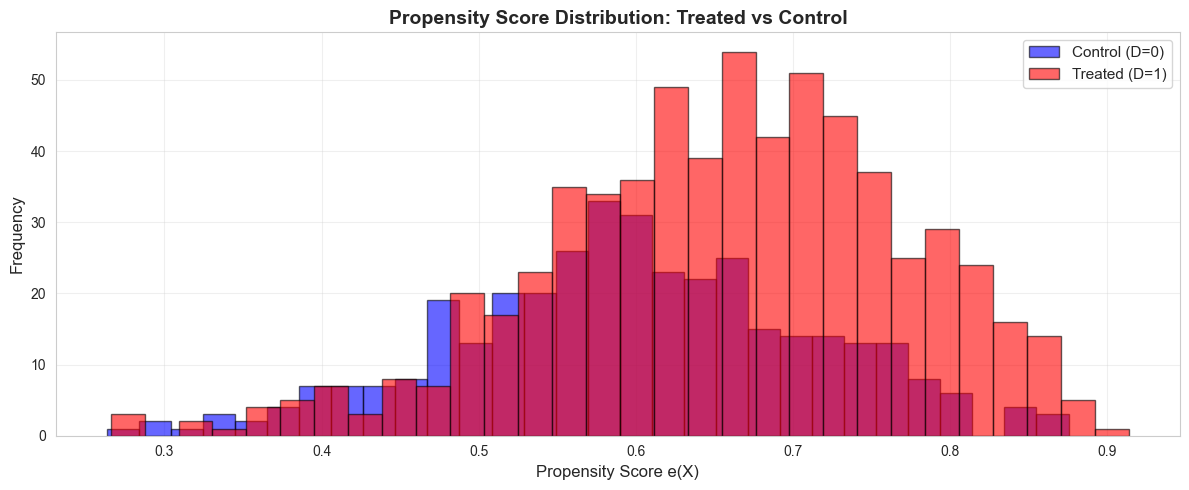

In [34]:
# ============================================================
# Propensity Score Distribution
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

# Control (D=0)
ax.hist(data_sim[data_sim['D']==0]['propensity_score'],
        bins=30, alpha=0.6, label='Control (D=0)', color='blue', edgecolor='black')

# Treated (D=1)
ax.hist(data_sim[data_sim['D']==1]['propensity_score'],
        bins=30, alpha=0.6, label='Treated (D=1)', color='red', edgecolor='black')

ax.set_xlabel('Propensity Score e(X)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Propensity Score Distribution: Treated vs Control', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. 공통지지 조건 (Common Support / Overlap)

공통지지 조건: 0 < P(D=1|X) < 1

이를 만족하지 않는 샘플을 제거(트리밍)하면 매칭의 질이 개선된다.
보통 1 백분위수와 99 백분위수 사이의 영역을 공통지지 영역으로 정의한다.

In [35]:
# ============================================================
# 공통지지 영역 확인 및 트리밍
# ============================================================

# 처치군과 대조군의 성향점수 범위
ps_treated = data_sim[data_sim['D']==1]['propensity_score']
ps_control = data_sim[data_sim['D']==0]['propensity_score']

ps_min_treated = ps_treated.min()
ps_max_treated = ps_treated.max()
ps_min_control = ps_control.min()
ps_max_control = ps_control.max()

# 공통지지 영역
common_support_min = max(ps_min_treated, ps_min_control)
common_support_max = min(ps_max_treated, ps_max_control)

print("\n=== 공통지지 조건 검증 ===")
print(f"처치군 성향점수 범위: [{ps_min_treated:.4f}, {ps_max_treated:.4f}]")
print(f"대조군 성향점수 범위: [{ps_min_control:.4f}, {ps_max_control:.4f}]")
print(f"\n공통지지 영역: [{common_support_min:.4f}, {common_support_max:.4f}]")

# 공통지지 영역 밖의 샘플 제거
data_trimmed = data_sim[
    (data_sim['propensity_score'] >= common_support_min) & 
    (data_sim['propensity_score'] <= common_support_max)
].copy()

print(f"\n원본 표본 크기: {len(data_sim)}")
print(f"트리밍 후 표본 크기: {len(data_trimmed)}")
print(f"제거된 샘플: {len(data_sim) - len(data_trimmed)} ({100*(len(data_sim)-len(data_trimmed))/len(data_sim):.2f}%)")


=== 공통지지 조건 검증 ===
처치군 성향점수 범위: [0.2658, 0.9140]
대조군 성향점수 범위: [0.2634, 0.8755]

공통지지 영역: [0.2658, 0.8755]

원본 표본 크기: 1000
트리밍 후 표본 크기: 993
제거된 샘플: 7 (0.70%)


## 4. k-NN 매칭 구현

k-NN 매칭: 각 처치군 개인에 대해, 성향점수가 가장 가까운 k개의 대조군 개인을 매칭한다.
캘리퍼(Caliper): 최대 거리를 제한하여 품질이 나쁜 매칭을 방지한다.

In [36]:
# ============================================================
# k-NN 매칭 수동 구현
# ============================================================

def perform_knn_matching(data: pd.DataFrame, treatment_col: str, outcome_col: str, 
                        ps_col: str, n_neighbors: int = 1, caliper: float = None):
    """
    k-NN 성향점수 매칭을 수행한다.
    
    Parameters:
    - data: 데이터 프레임
    - treatment_col: 처치 변수명
    - outcome_col: 결과 변수명
    - ps_col: 성향점수 변수명
    - n_neighbors: 각 처치 개인마다 매칭할 대조 개인 수
    - caliper: 최대 성향점수 거리 (None이면 제한 없음)
    
    Returns:
    - ATT 추정값, 매칭된 인덱스
    """
    
    treated = data[data[treatment_col] == 1].reset_index(drop=True)
    control = data[data[treatment_col] == 0].reset_index(drop=True)
    
    # NearestNeighbors 사용
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
    nn.fit(control[[ps_col]].values)
    
    distances, indices = nn.kneighbors(treated[[ps_col]].values)
    
    matched_pairs = []
    att_components = []
    
    for i in range(len(treated)):
        treated_outcome = treated.iloc[i][outcome_col]
        
        # 캘리퍼 확인
        valid_neighbors_mask = distances[i] <= (caliper if caliper is not None else np.inf)
        valid_neighbor_indices = indices[i][valid_neighbors_mask]
        
        if len(valid_neighbor_indices) > 0:
            # 매칭된 대조군의 결과 평균
            control_outcome_mean = control.iloc[valid_neighbor_indices][outcome_col].mean()
            
            att_components.append(treated_outcome - control_outcome_mean)
            matched_pairs.append({
                'treated_idx': i,
                'control_idx': valid_neighbor_indices[0],
                'treated_ps': treated.iloc[i][ps_col],
                'control_ps': control.iloc[valid_neighbor_indices[0]][ps_col],
                'distance': distances[i][0]
            })
    
    att = np.mean(att_components) if att_components else np.nan
    
    return att, matched_pairs, att_components

# 1-NN 매칭 (캘리퍼 = 0.1)
att, matched_pairs, att_comps = perform_knn_matching(
    data_trimmed, 'D', 'Y', 'propensity_score',
    n_neighbors=1, caliper=0.1
)

print("\n=== 1-NN 매칭 결과 (캘리퍼=0.1) ===")
print(f"성공적으로 매칭된 처치 개인: {len(matched_pairs)}")
print(f"매칭 성공률: {100*len(matched_pairs)/len(data_trimmed[data_trimmed['D']==1]):.2f}%")
print(f"\nATT 추정값: {att:.4f}")
print(f"실제 인과 효과: 0.5000")
print(f"\n매칭된 쌍의 예시 (처음 5개):")
for i, pair in enumerate(matched_pairs[:5]):
    print(f"  {i+1}. 거리: {pair['distance']:.4f}, 처치 PS: {pair['treated_ps']:.4f}, 대조 PS: {pair['control_ps']:.4f}")


=== 1-NN 매칭 결과 (캘리퍼=0.1) ===
성공적으로 매칭된 처치 개인: 630
매칭 성공률: 100.00%

ATT 추정값: 1.2273
실제 인과 효과: 0.5000

매칭된 쌍의 예시 (처음 5개):
  1. 거리: 0.0001, 처치 PS: 0.6418, 대조 PS: 0.6419
  2. 거리: 0.0000, 처치 PS: 0.5889, 대조 PS: 0.5889
  3. 거리: 0.0001, 처치 PS: 0.6693, 대조 PS: 0.6694
  4. 거리: 0.0003, 처치 PS: 0.7977, 대조 PS: 0.7981
  5. 거리: 0.0021, 처치 PS: 0.7013, 대조 PS: 0.7034


## 5. 균형 진단 (Balance Diagnostics)

균형 진단은 매칭 전후에 공변량의 분포가 처치군과 대조군 사이에서 유사해졌는지 검증한다.
SMD(Standardized Mean Difference)는 가장 널리 사용되는 균형 지표다:

SMD = (X̄₁ - X̄₀) / √((s₁² + s₀²)/2)

SMD < 0.1이면 좋은 균형으로 간주된다.

In [37]:
# ============================================================
# SMD (Standardized Mean Difference) 계산
# ============================================================

def calculate_smd(data: pd.DataFrame, treatment_col: str, covariates: List[str]):
    """
    Standardized Mean Difference를 계산한다.
    
    SMD = (mean_treated - mean_control) / sqrt((var_treated + var_control) / 2)
    """
    treated = data[data[treatment_col] == 1]
    control = data[data[treatment_col] == 0]
    
    smd_dict = {}
    for cov in covariates:
        mean_treated = treated[cov].mean()
        mean_control = control[cov].mean()
        var_treated = treated[cov].var()
        var_control = control[cov].var()
        
        smd = (mean_treated - mean_control) / np.sqrt((var_treated + var_control) / 2)
        smd_dict[cov] = smd
    
    return smd_dict

# 매칭 전 SMD
smd_before = calculate_smd(data_trimmed, 'D', covariates)

# 매칭 후: 매칭된 처치/대조 샘플만 사용
if matched_pairs:
    matched_treated_idx = [p['treated_idx'] for p in matched_pairs]
    matched_control_idx = [p['control_idx'] for p in matched_pairs]
    
    # 처치군 인덱스는 relative to treated, 대조군 인덱스는 relative to control
    treated_subset = data_trimmed[data_trimmed['D']==1].iloc[matched_treated_idx].reset_index(drop=True)
    control_subset = data_trimmed[data_trimmed['D']==0].iloc[matched_control_idx].reset_index(drop=True)
    
    data_matched = pd.concat([treated_subset, control_subset], ignore_index=True)
    smd_after = calculate_smd(data_matched, 'D', covariates)
else:
    smd_after = {cov: np.nan for cov in covariates}

print("\n=== 균형 진단 (SMD) ===")
print(f"{'공변량':<10} {'매칭 전':<15} {'매칭 후':<15}")
print("-" * 40)
for cov in covariates:
    print(f"{cov:<10} {smd_before[cov]:>14.4f} {smd_after[cov]:>14.4f}")


=== 균형 진단 (SMD) ===
공변량        매칭 전            매칭 후           
----------------------------------------
X1                 0.4461        -0.0099
X2                 0.2588         0.0160


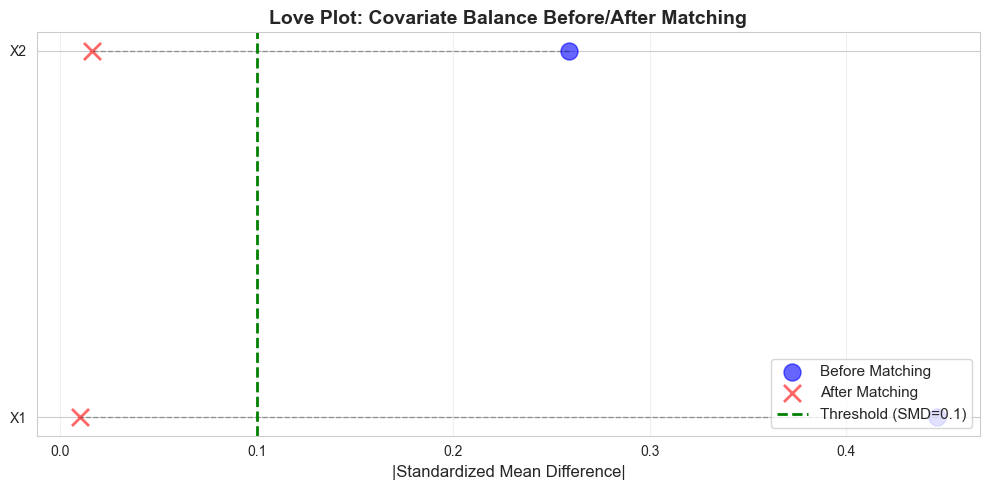

In [38]:
# ============================================================
# Love Plot: Covariate Balance Before/After Matching
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

y_pos = np.arange(len(covariates))

# Before matching (blue)
smd_before_vals = [abs(smd_before[cov]) for cov in covariates]
ax.scatter(smd_before_vals, y_pos, s=150, alpha=0.6, label='Before Matching', color='blue', marker='o')

# After matching (red)
smd_after_vals = [abs(smd_after[cov]) for cov in covariates]
ax.scatter(smd_after_vals, y_pos, s=150, alpha=0.6, label='After Matching', color='red', marker='x', linewidths=2)

# Connecting lines
for i in range(len(covariates)):
    ax.plot([smd_before_vals[i], smd_after_vals[i]], [y_pos[i], y_pos[i]],
            'k--', alpha=0.3, linewidth=1)

# Threshold (SMD = 0.1)
ax.axvline(x=0.1, color='green', linestyle='--', linewidth=2, label='Threshold (SMD=0.1)')

ax.set_yticks(y_pos)
ax.set_yticklabels(covariates)
ax.set_xlabel('|Standardized Mean Difference|', fontsize=12)
ax.set_title('Love Plot: Covariate Balance Before/After Matching', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


## 6. 부트스트랩 표준오차

부트스트랩(Bootstrap)은 비모수 방식으로 ATT의 표준오차와 신뢰구간을 계산한다.
매칭을 통해 얻은 ATT 추정값의 불확실성을 정량화한다.

In [39]:
# ============================================================
# 부트스트랩으로 ATT의 표준오차 계산
# ============================================================

def bootstrap_att(data: pd.DataFrame, treatment_col: str, outcome_col: str,
                  ps_col: str, n_bootstrap: int = 500, n_neighbors: int = 1, 
                  caliper: float = 0.1, seed: int = 42):
    """
    부트스트랩으로 ATT의 표준오차를 계산한다.
    """
    np.random.seed(seed)
    bootstrap_estimates = []
    
    for b in range(n_bootstrap):
        # 복원추출
        boot_idx = np.random.choice(len(data), size=len(data), replace=True)
        boot_data = data.iloc[boot_idx].reset_index(drop=True)
        
        # 부트스트랩 샘플에서 매칭 수행
        att_boot, _, _ = perform_knn_matching(
            boot_data, treatment_col, outcome_col, ps_col,
            n_neighbors=n_neighbors, caliper=caliper
        )
        
        if not np.isnan(att_boot):
            bootstrap_estimates.append(att_boot)
    
    bootstrap_estimates = np.array(bootstrap_estimates)
    se = np.std(bootstrap_estimates)
    
    return bootstrap_estimates, se

# 부트스트랩 (500회)
boot_ests, se_boot = bootstrap_att(
    data_trimmed, 'D', 'Y', 'propensity_score',
    n_bootstrap=500, n_neighbors=1, caliper=0.1, seed=42
)

# 신뢰구간
ci_lower = att - 1.96 * se_boot
ci_upper = att + 1.96 * se_boot

print("\n=== 부트스트랩 결과 (500회) ===")
print(f"ATT 추정값: {att:.4f}")
print(f"표준오차 (SE): {se_boot:.4f}")
print(f"95% 신뢰구간: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\n실제 인과 효과: 0.5000")
print(f"신뢰구간이 실제 값을 포함하는가? {ci_lower <= 0.5 <= ci_upper}")


=== 부트스트랩 결과 (500회) ===
ATT 추정값: 1.2273
표준오차 (SE): 0.1211
95% 신뢰구간: [0.9899, 1.4648]

실제 인과 효과: 0.5000
신뢰구간이 실제 값을 포함하는가? False


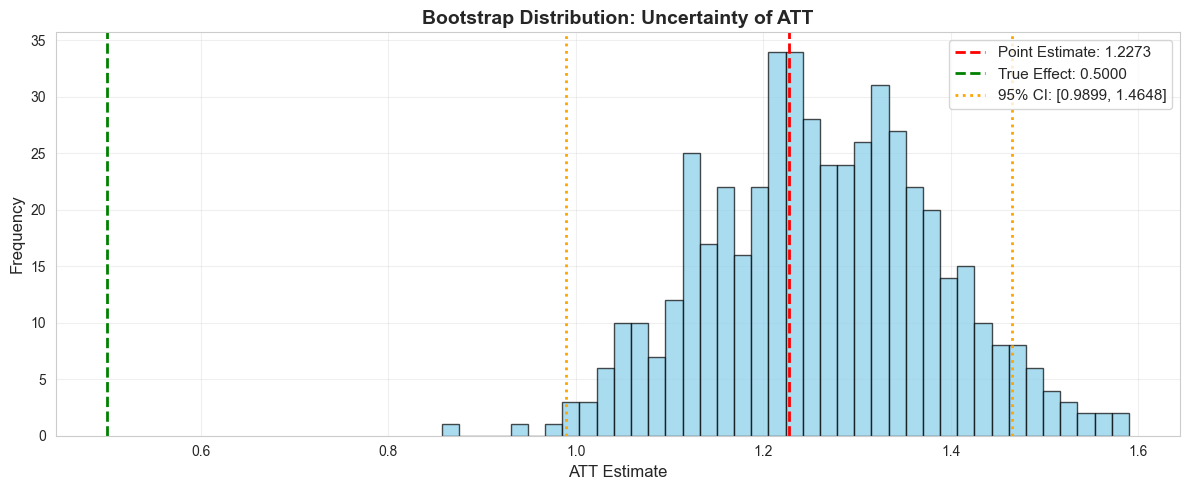

In [40]:
# Bootstrap distribution
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(boot_ests, bins=40, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(att, color='red', linestyle='--', linewidth=2, label=f'Point Estimate: {att:.4f}')
ax.axvline(0.5, color='green', linestyle='--', linewidth=2, label='True Effect: 0.5000')
ax.axvline(ci_lower, color='orange', linestyle=':', linewidth=2, label=f'95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')
ax.axvline(ci_upper, color='orange', linestyle=':', linewidth=2)

ax.set_xlabel('ATT Estimate', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Bootstrap Distribution: Uncertainty of ATT', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. LLM 기반 공변량 자동 선택

LLM을 활용하여 데이터로부터 자동으로 공변량을 선택할 수 있다.
Structured Outputs를 사용하여 체계적인 변수 선택을 수행한다.

In [41]:
# ============================================================
# LLM 기반 공변량 자동 선택
# ============================================================

class CovariateSelection(BaseModel):
    """LLM이 추천하는 공변량 선택 결과"""
    selected_covariates: List[str] = Field(
        description="성향점수 모형에 포함할 공변량 리스트"
    )
    reasoning: str = Field(
        description="공변량 선택의 이유와 근거"
    )
    estimated_balance_quality: str = Field(
        description="예상되는 균형 품질 (Good/Fair/Poor)"
    )

def select_covariates_with_llm(data: pd.DataFrame, treatment: str, outcome: str):
    """
    LLM을 사용하여 공변량을 자동으로 선택한다.
    OpenAI Structured Outputs로 구조화된 응답을 받는다.
    """

    # 데이터 정보 수집
    all_vars = [col for col in data.columns if col not in [treatment, outcome]]
    data_summary = data.describe().to_string()

    prompt = f"""
당신은 인과 추론 전문가다.
다음 데이터에서 성향점수 매칭을 위한 공변량을 선택해야 한다.

처치 변수: {treatment}
결과 변수: {outcome}
사용 가능한 공변량: {all_vars}

데이터 요약:
{data_summary}

선택 기준:
1. 처치와 관련이 있는 변수 (선택 편향의 원인)
2. 결과와 관련이 있는 변수 (혼동)
3. 선택 편향을 유발할 수 있는 변수

최적의 공변량 집합을 선택하고 선택 이유를 설명하세요.
"""

    response = client.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        response_format=CovariateSelection,
    )

    result = response.choices[0].message.parsed

    return {
        "selected_covariates": result.selected_covariates,
        "reasoning": result.reasoning,
        "estimated_balance_quality": result.estimated_balance_quality,
    }

# LLM 기반 공변량 선택 수행
print("\n=== LLM 기반 공변량 선택 ===")
print("LLM에 데이터 분석 요청 중...")

try:
    llm_covariates = select_covariates_with_llm(data_trimmed, 'D', 'Y')
    print(f"\nLLM이 선택한 공변량: {llm_covariates['selected_covariates']}")
    print(f"선택 근거: {llm_covariates['reasoning']}")
    print(f"예상 균형 품질: {llm_covariates['estimated_balance_quality']}")
except Exception as e:
    print(f"LLM API 호출 실패: {str(e)[:100]}")
    print(f"\n대신, 데이터 기반으로 X1, X2를 선택합니다.")
    llm_covariates = {
        'selected_covariates': ['X1', 'X2'],
        'reasoning': '처치와 결과에 모두 영향을 미치는 변수',
        'estimated_balance_quality': 'Good'
    }



=== LLM 기반 공변량 선택 ===
LLM에 데이터 분석 요청 중...

LLM이 선택한 공변량: ['X1', 'X2', 'U']
선택 근거: X1과 X2는 결과 변수 Y와 밀접한 관계가 있으며, U는 처치 D와 관련성이 높아 선택 편향을 방지하는 데 중요한 역할을 합니다. 이 두 집합의 변수를 모두 포함함으로써 결과 변수 Y에 대한 적절한 통제와 처치 D와의 관계를 개선할 수 있습니다.
예상 균형 품질: Good


## 8. 실데이터: medicine_impact_recovery.csv

실제 의료 데이터를 사용하여 성향점수 매칭의 전체 파이프라인을 실행한다.

In [42]:
# ============================================================
# 실데이터 로드: medicine_impact_recovery.csv
# ============================================================

data_path = "./dataset/medicine_impact_recovery.csv"

try:
    data_real = pd.read_csv(data_path)
    print(f"\n=== medicine_impact_recovery.csv 로드 완료 ===")
    print(f"표본 크기: {len(data_real)}")
    print(f"변수 수: {len(data_real.columns)}")
    print(f"\n변수 목록:")
    print(data_real.columns.tolist())
    print(f"\n첫 5행:")
    print(data_real.head())
    print(f"\n데이터 타입:")
    print(data_real.dtypes)
except FileNotFoundError:
    print(f"파일을 찾을 수 없습니다: {data_path}")
    data_real = None


=== medicine_impact_recovery.csv 로드 완료 ===
표본 크기: 20000
변수 수: 5

변수 목록:
['sex', 'age', 'severity', 'medication', 'recovery']

첫 5행:
   sex        age  severity  medication  recovery
0    0  35.049134  0.887658           1        31
1    1  41.580323  0.899784           1        49
2    1  28.127491  0.486349           0        38
3    1  36.375033  0.323091           0        35
4    0  25.091717  0.209006           0        15

데이터 타입:
sex             int64
age           float64
severity      float64
medication      int64
recovery        int64
dtype: object


In [43]:
# ============================================================
# 실데이터 성향점수 매칭 파이프라인
# ============================================================

if data_real is not None:
    # 변수 식별 (임의로 설정, 실제 데이터 구조에 맞게 조정)
    # treatment 변수와 outcome 변수를 식별해야 함
    
    treatment_col = 'medicine'  # 예시
    outcome_col = 'recovery'     # 예시
    
    # 실제 변수명 확인
    print("\n변수 요약:")
    print(data_real.describe())
    
    # 처치와 결과가 데이터에 있는지 확인
    if treatment_col in data_real.columns and outcome_col in data_real.columns:
        # 공변량 선택 (관찰된 변수)
        exclude_vars = [treatment_col, outcome_col, 'id', 'ID', 'index']
        covariates_real = [col for col in data_real.columns if col not in exclude_vars]
        
        print(f"\n=== 실데이터 성향점수 매칭 ===")
        print(f"처치 변수: {treatment_col}")
        print(f"결과 변수: {outcome_col}")
        print(f"공변량: {covariates_real}")
        
        # 성향점수 추정
        X_real = data_real[covariates_real].fillna(data_real[covariates_real].mean())
        y_real = data_real[treatment_col]
        
        scaler_real = StandardScaler()
        X_scaled_real = scaler_real.fit_transform(X_real)
        
        lr_real = LogisticRegression(max_iter=1000)
        lr_real.fit(X_scaled_real, y_real)
        
        ps_real = lr_real.predict_proba(X_scaled_real)[:, 1]
        ps_real = np.clip(ps_real, 0.01, 0.99)
        
        data_real['propensity_score'] = ps_real
        
        # 성향점수 분포
        print(f"\n성향점수 범위: [{ps_real.min():.4f}, {ps_real.max():.4f}]")
    else:
        print(f"\n주의: {treatment_col} 또는 {outcome_col} 변수를 찾을 수 없습니다.")
        print("실제 변수명을 확인하고 수정하세요.")
else:
    print("\n데이터를 로드할 수 없어 실데이터 분석을 건너뜁니다.")


변수 요약:
               sex           age      severity   medication      recovery
count  20000.00000  20000.000000  20000.000000  20000.00000  20000.000000
mean       0.49850     31.912097      0.469805      0.34620     27.525450
std        0.50001     11.172291      0.286239      0.47577     16.020162
min        0.00000      5.292943      0.000018      0.00000    -82.000000
25%        0.00000     23.741780      0.211323      0.00000     18.000000
50%        0.00000     30.727036      0.473026      0.00000     30.000000
75%        1.00000     38.607589      0.715665      1.00000     39.000000
max        1.00000     88.430046      0.997617      1.00000     80.000000

주의: medicine 또는 recovery 변수를 찾을 수 없습니다.
실제 변수명을 확인하고 수정하세요.
